In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.append(str(project_root))

print("Project root added:", project_root)


Project root added: C:\Users\HP\Desktop\quant-trading-strategy-backtest


In [2]:
import yfinance as yf
import pandas as pd

In [3]:

tickers = ["SPY", "QQQ"]
price_data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start="2015-01-01",
        end="2024-01-01",
        progress=False,
        auto_adjust=False,
        threads=False
    )
    
    if df is None or df.empty:
        raise ValueError(f"Download failed for {ticker}")
    
    price_data[ticker] = df["Close"]


prices = pd.concat(price_data, axis=1)


prices.to_csv("C:/Users/HP/Desktop/quant-trading-strategy-backtest/data/price_data.csv")

prices.head()


,SPY,QQQ
Ticker,SPY,QQQ
Date,,
2015-01-02,205.429993,102.940002
2015-01-05,201.720001,101.430000
2015-01-06,199.820007,100.070000
2015-01-07,202.309998,101.360001
2015-01-08,205.899994,103.300003


In [4]:
import sys
from pathlib import Path

In [5]:
project_root = Path("...").resolve()
sys.path.append(str(project_root))

In [6]:
from src.data_loader import load_price_data
prices = load_price_data()
prices.head()

,SPY,QQQ
2015-01-02,205.429993,102.940002
2015-01-05,201.720001,101.430000
2015-01-06,199.820007,100.070000
2015-01-07,202.309998,101.360001
2015-01-08,205.899994,103.300003


In [7]:
from src.data_loader import load_price_data
from src.signals import momentum_signal

prices = load_price_data()
momentum = momentum_signal(prices)

momentum.head(25)

,SPY,QQQ
2015-01-02,NaN,NaN
2015-01-05,NaN,NaN
2015-01-06,NaN,NaN
2015-01-07,NaN,NaN
2015-01-08,NaN,NaN
2015-01-09,NaN,NaN
2015-01-12,NaN,NaN
2015-01-13,NaN,NaN
2015-01-14,NaN,NaN
2015-01-15,NaN,NaN


In [8]:
from src.signals import momentum_signal, momentum_positions

momentum = momentum_signal(prices)
positions = momentum_positions(momentum)

positions.tail()


,SPY,QQQ
2023-12-22,1,1
2023-12-26,1,1
2023-12-27,1,1
2023-12-28,1,1
2023-12-29,1,1


In [9]:
positions.iloc[50:80]

,SPY,QQQ
2015-03-17,0,0
2015-03-18,1,1
2015-03-19,0,1
2015-03-20,0,1
2015-03-23,0,0
2015-03-24,0,0
2015-03-25,0,0
2015-03-26,0,0
2015-03-27,0,0
2015-03-30,0,0


In [10]:
positions.mean()

SPY    0.647527
QQQ    0.655919
dtype: float64

<Axes: title={'center': '2023'}>

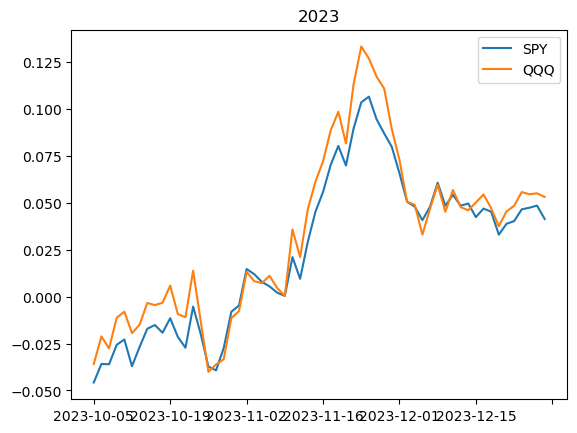

In [11]:
momentum.tail(60).plot(title="2023")

In [12]:
positions.nunique()

SPY    2
QQQ    2
dtype: int64

In [13]:
from src.backtest import run_backtest
portfolio_returns = run_backtest(prices, positions)
portfolio_returns.tail()

2023-12-22    0.001753
2023-12-26    0.005172
2023-12-27    0.001659
2023-12-28   -0.000054
2023-12-29   -0.003611
dtype: float64

In [14]:
portfolio_returns.mean()

0.0011756160159267478

In [15]:
portfolio_returns.std()

0.006854868114837522

In [16]:
len(portfolio_returns)

2264

In [17]:
equity_curve = (1 + portfolio_returns).cumprod()
equity_curve.tail()

2023-12-22    13.501390
2023-12-26    13.571221
2023-12-27    13.593729
2023-12-28    13.592993
2023-12-29    13.543904
dtype: float64

In [18]:
import matplotlib.pyplot as plt

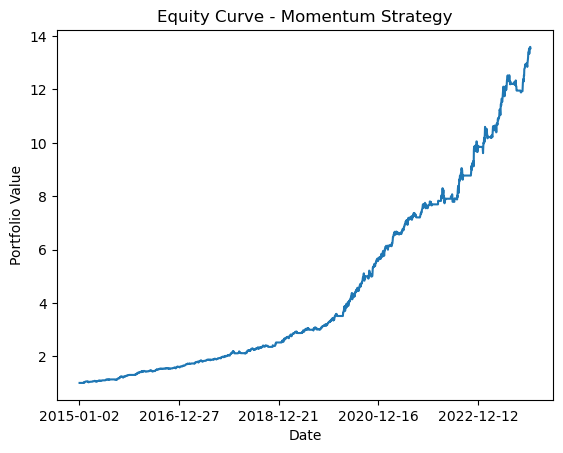

In [19]:
plt.figure()
equity_curve.plot()
plt.title("Equity Curve - Momentum Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.show()

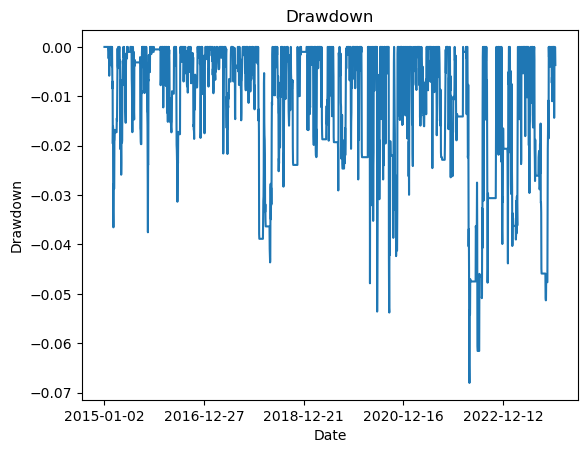

In [20]:
rolling_max = equity_curve.cummax()
drawdown = equity_curve / rolling_max - 1

plt.figure()
drawdown.plot()
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

In [21]:
equity_curve.iloc[-1]

13.543903957778312

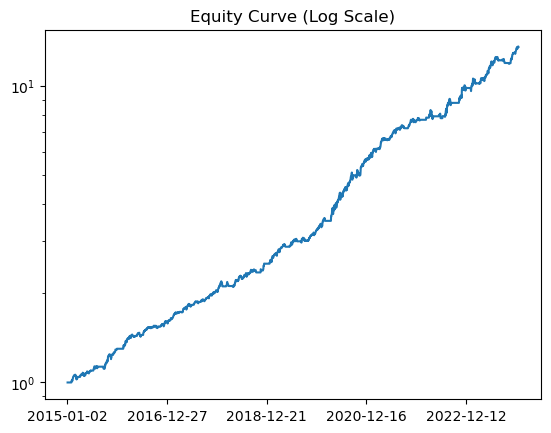

In [22]:
equity_curve.plot(logy = True, title = "Equity Curve (Log Scale)")
plt.show()

In [47]:
from src.performance import performance_metrics

In [49]:
metrics = performance_metrics(portfolio_returns)
metrics

{'Total Return': 12.543903957778312,
 'Volatility': 0.10881765781203741,
 'Sharpe Ratio': 2.722492304744026,
 'Max Drawdown': -0.06804578934314898,
 'Hit Ratio': 0.4204946996466431}

In [51]:
metrics_df = pd.DataFrame.from_dict(metrics, orient = "index", columns = ["Value"])
metrics_df.to_csv("C:/Users/HP/Desktop/quant-trading-strategy-backtest/results/performance_summary.csv")

metrics_df

,Value
Total Return,12.543904
Volatility,0.108818
Sharpe Ratio,2.722492
Max Drawdown,-0.068046
Hit Ratio,0.420495
